In [1]:
# Parameters
name = "O_III-5007"
name_export = "O_III-5007_mask_bin_2"
bins = 1
flux_thresh = 0.001
sigma_thresh = 2.5


In [2]:
import time
start_time=time.time()
from pathlib import Path
import sys
import json
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [3]:
# Add path to pipeline_config.py
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse")
from pipeline_config import OBSERVATIONS_DIR, MAPS_DIR, FIGS_DIR 

# Add path to py_modules 
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules")
from rebin_utils import downsample
import region_observations_props as rop

# Input data

In [4]:
# Input FITS files
flux_path    = OBSERVATIONS_DIR / f'linesum-{name}.fits'
radvel_path  = OBSERVATIONS_DIR / f'mean-{name}-patfixx.fits'

# Open files
flux    = fits.open(flux_path)
rad_vel = fits.open(radvel_path)


In [5]:
# Region and astronomical observation properties

pix = rop.pixel_scale # spatialscale [arcsec per pixel]
pc  = rop.pc          # value in parsecs of each arcsec
s0  = rop.s0          # RMS seeing [parsecs]

print(pix , pc, s0)

0.2 0.0019877360925490972 0.0007596443665792729


In [6]:
sb = flux[0].data.astype(float)
vv = rad_vel[0].data.astype(float)

sb_og = sb
vv_og = vv

box_size = np.sqrt(sb.shape[0] * sb.shape[1]) * pix * pc
print(box_size)

0.6418406922107823


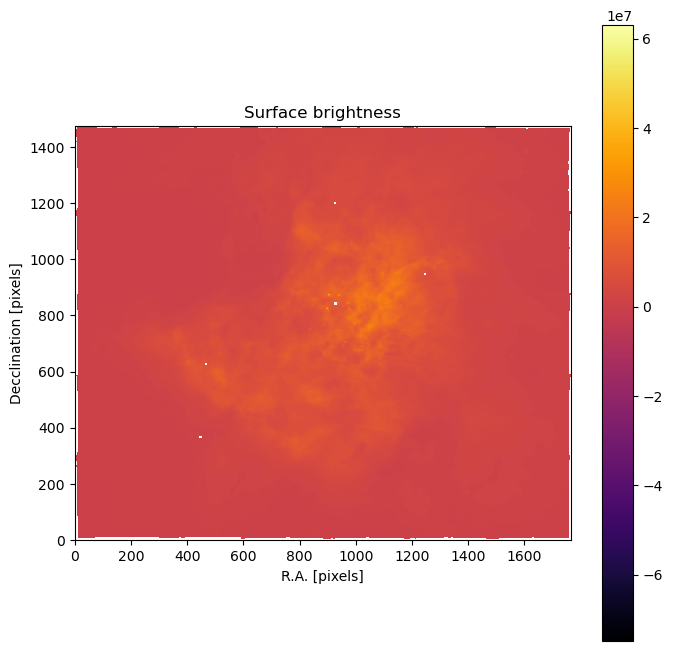

In [7]:
# Surface brightness map

fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(sb, cmap='inferno')

cbar = plt.colorbar()
#plt.clim(0.001,1)
cbar.set_label(' ', rotation=270, labelpad=15)  

ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Surface brightness')

plt.gca().invert_yaxis()

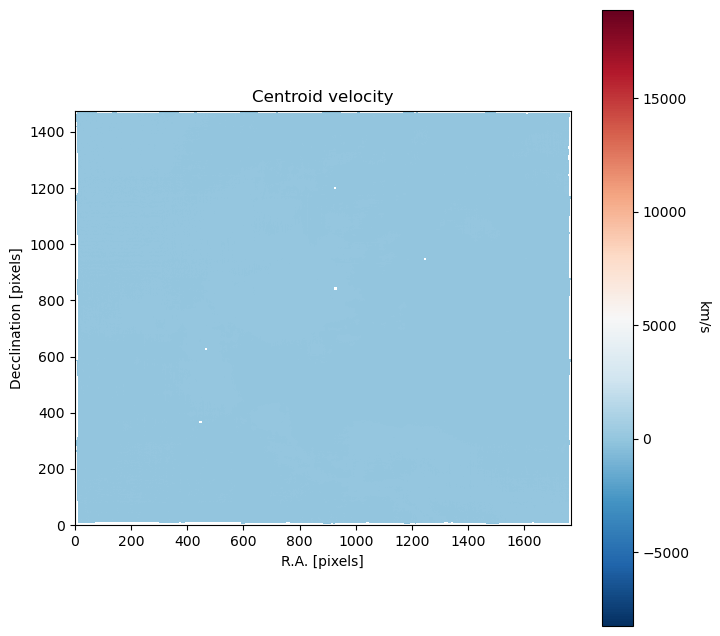

In [8]:
# Velocity map

fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(vv, cmap='RdBu_r')

cbar = plt.colorbar()
#plt.clim(5,25)
cbar.set_label('km/s', rotation=270, labelpad=15)  

ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Centroid velocity')

plt.gca().invert_yaxis()

# Downsample

In [9]:
prod_map  = sb * vv
sb_       = pd.notna(sb)
vv_       = pd.notna(vv)
prod_map_ = sb_ * vv_

In [10]:
mingoods  = [1]*bins

for mingood in zip(mingoods):
 [sb], sb_= downsample([sb], sb_, mingood=mingood)

for mingood in zip(mingoods):
 [prod_map], prod_map_= downsample([prod_map], prod_map_, mingood=mingood)

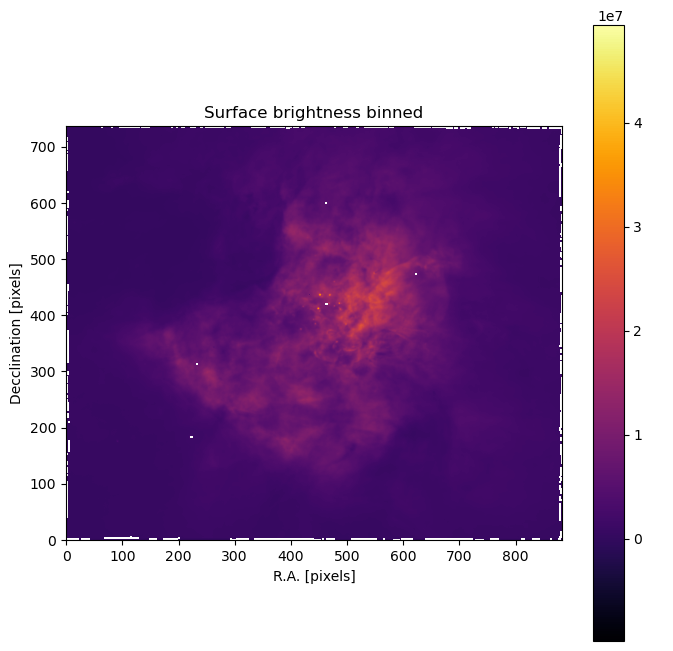

In [11]:
# Surface brightness binned map

fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(sb, cmap='inferno')

cbar = plt.colorbar()
#plt.clim(0.001,1)
cbar.set_label(' ', rotation=270, labelpad=15)  

ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Surface brightness binned')

plt.gca().invert_yaxis()

C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_5452\277074649.py:2: RuntimeWarning: invalid value encountered in divide
  vv = prod_map/sb


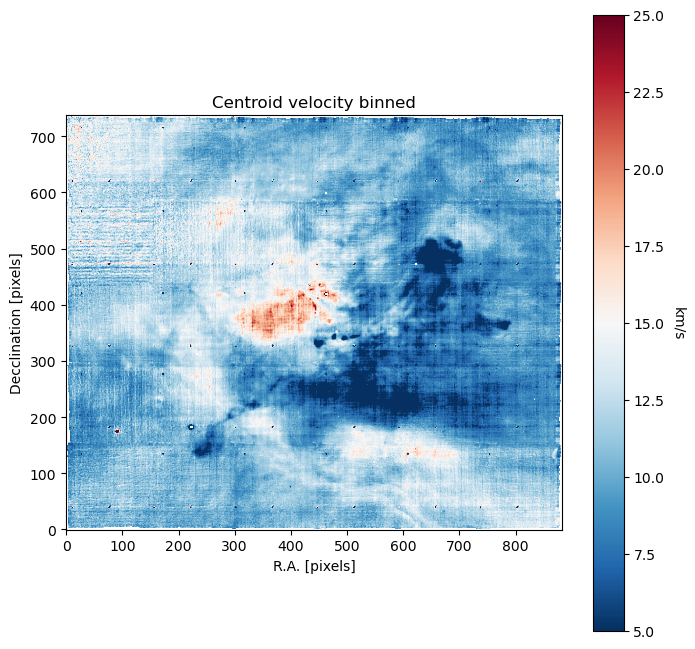

In [12]:
# Velocity binned map
vv = prod_map/sb


fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(vv, cmap='RdBu_r')

cbar = plt.colorbar()
plt.clim(5,25)
cbar.set_label('km/s', rotation=270, labelpad=15)  

ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Centroid velocity binned')

plt.gca().invert_yaxis()

In [13]:
sb_ds = sb
vv_ds = vv

In [14]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv) | (sb < 0.0)

sb[m] = 0.0
vv[m] = np.nanmean(vv)
sb /= sb.max()

# Mask

In [15]:
# The information in the matrices is converted to a pandas data frame (list form).
# Then the information in the form of list needs to be converted to a matrix again.
# I need to check for other options for performing the mask.

sb_df       = pd.DataFrame(sb)
sb_df       = sb_df.stack().reset_index().rename(columns={'level_0':'X', 'level_1':'Y', 0:'I'})
vv_df       = pd.DataFrame(vv)
data        = vv_df.stack().reset_index().rename(columns={'level_0':'X', 'level_1':'Y', 0:'RV'})
data['I']   = sb_df.I

In [16]:
data.describe()

,X,Y,RV,I
count,651654.000000,651654.000000,651654.000000,651654.000000
mean,368.500000,441.000000,10.634727,0.067855
std,213.042217,254.900176,5.639432,0.073072
min,0.000000,0.000000,-895.188037,0.000000
25%,184.000000,220.000000,9.011193,0.020750
50%,368.500000,441.000000,10.618386,0.037094
75%,553.000000,662.000000,12.280385,0.093057
max,737.000000,882.000000,3156.466178,1.000000


In [17]:
#sns.pairplot(data, 
#             vars=["I","RV"], 
#             diag_kind='hist',  
#             plot_kws=dict(alpha=0.3, s=10, edgecolor='none'),
#             diag_kws=dict(bins=20),
#            )

In [18]:
mask = (data.I > flux_thresh) & \
(data.RV > data.RV.mean() - sigma_thresh*data.RV.std()) & (data.RV < data.RV.mean() + sigma_thresh*data.RV.std())

In [19]:
#sns.pairplot(data[mask], 
#             vars=["I","RV"], 
#             diag_kind='hist',  
#             plot_kws=dict(alpha=0.3, s=10, edgecolor='none'),
#             diag_kws=dict(bins=20),
#            )

In [20]:
data[mask].describe()

,X,Y,RV,I
count,640717.000000,640717.000000,640717.000000,640717.000000
mean,368.060378,440.489753,10.644786,0.068816
std,211.388959,252.993742,2.753709,0.073034
min,0.000000,0.000000,-3.451326,0.002231
25%,185.000000,221.000000,8.985703,0.021410
50%,368.000000,440.000000,10.611750,0.037950
75%,551.000000,660.000000,12.312616,0.094464
max,737.000000,882.000000,24.689283,0.897039


In [21]:
sb_mask = (data[mask].round(2)).pivot(index='X', columns='Y', values='I')
vv_mask = (data[mask].round(2)).pivot(index='X', columns='Y', values='RV')

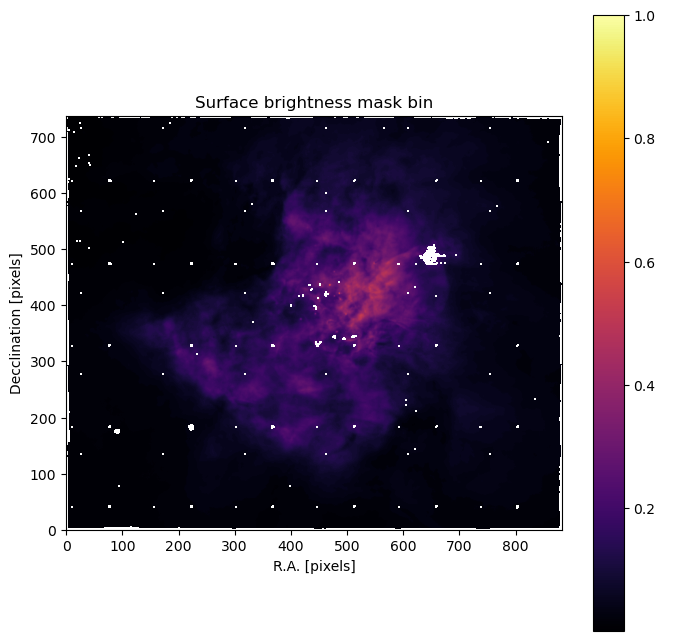

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))

plt.figure(1)
plt.imshow(sb_mask, cmap='inferno')

cbar = plt.colorbar()
plt.clim(0.001,1)
cbar.set_label(' ', rotation=270, labelpad=15)  

ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Surface brightness mask bin')

plt.gca().invert_yaxis()

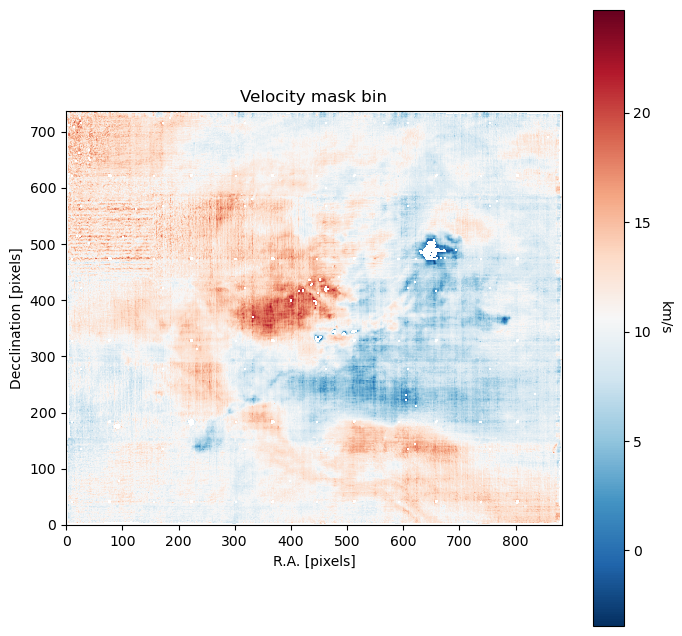

In [23]:
fig, ax = plt.subplots(figsize=(8,8))


plt.figure(1)
plt.imshow(vv_mask, cmap='RdBu_r')

cbar = plt.colorbar()
#plt.clim(5,25)
cbar.set_label('km/s', rotation=270, labelpad=15)  


ax.set_xlabel('R.A. [pixels]')
ax.set_ylabel('Decclination [pixels]')
ax.set_title('Velocity mask bin')

plt.gca().invert_yaxis()

# Export data

In [24]:
## Replace spurious values in the arrays
m_og = ~np.isfinite(sb_og*vv_og) | (sb_og < 0.0)

sb_og[m_og] = 0.0
vv_og[m_og] = np.nanmean(vv_og)
sb_og /= sb_og.max()

In [25]:
## Replace spurious values in the arrays
m_ds = ~np.isfinite(sb_ds*vv_ds) | (sb_ds < 0.0)

sb_ds[m_ds] = 0.0
vv_ds[m_ds] = np.nanmean(vv_ds)
sb_ds /= sb_ds.max()

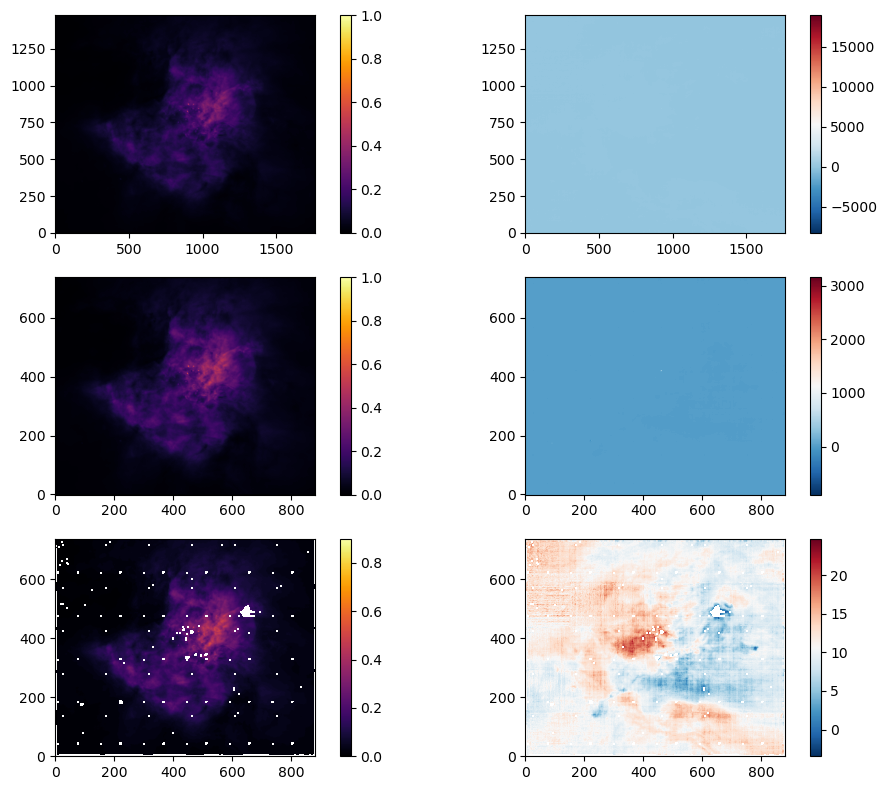

In [26]:
fig, ax = plt.subplots(3, 2, figsize=(10, 8))

# Original data
im0 = ax[0, 0].imshow(sb_og, cmap='inferno', origin='lower')
im1 = ax[0, 1].imshow(vv_og, cmap='RdBu_r', origin='lower')

# Binned data
im2 = ax[1, 0].imshow(sb_ds, cmap='inferno', origin='lower')
im3 = ax[1, 1].imshow(vv_ds, cmap='RdBu_r', origin='lower')

# Masked data
im4 = ax[2, 0].imshow(sb_mask, cmap='inferno', origin='lower')
im5 = ax[2, 1].imshow(vv_mask, cmap='RdBu_r', origin='lower')

# Add individual colorbars
fig.colorbar(im0, ax=ax[0, 0])
fig.colorbar(im1, ax=ax[0, 1])
fig.colorbar(im2, ax=ax[1, 0])
fig.colorbar(im3, ax=ax[1, 1])
fig.colorbar(im4, ax=ax[2, 0])
fig.colorbar(im5, ax=ax[2, 1])

plt.tight_layout() 
fig_name = name + "_mask" + "_bin_" + str(2**bins) +"_maps.jpg"
fig.savefig(FIGS_DIR /fig_name)
plt.show()

In [27]:
data_export_matrix = {
       'name': name + "_mask_" +str(2**bins), 
       'pc' : pc,
       's0' : s0,
       'pix' : pix * (2**bins),
       'box_size' : box_size,
       'sb' : np.array(sb_mask),
       'vv' : np.array(vv_mask),
      }

data_export_matrix

{'name': 'O_III-5007_mask_2',
 'pc': 0.0019877360925490972,
 's0': 0.0007596443665792729,
 'pix': 0.4,
 'box_size': 0.6418406922107823,
 'sb': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan,  0., ..., nan, nan, nan],
        [nan, nan,  0., ..., nan, nan, nan],
        [nan, nan,  0., ..., nan, nan, nan]]),
 'vv': array([[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan,   nan, 10.  , ...,   nan,   nan,   nan],
        [  nan,   nan, 21.97, ...,   nan,   nan,   nan],
        [  nan,   nan, 17.65, ...,   nan,   nan,   nan]])}

In [28]:
class MyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)


In [29]:
jsonfilename = name + "_mask" + "_bin_" + str(2**bins) +".json"
with open(MAPS_DIR/jsonfilename, "w") as f:
    json.dump(data_export_matrix, fp=f, indent=3, cls=MyEncoder)

In [30]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 13.046861171722412 seconds ---
